In [2]:
import os
import pandas as pd

# Set the data path relative to the notebook location
data_path = "../Data/"

# Import data from the O*NET database, at ISCO-08 occupation level.
# The original data uses a version of SOC classification, but the data we load here
# are already cross-walked to ISCO-08 using: https://ibs.org.pl/en/resources/occupation-classifications-crosswalks-from-onet-soc-to-isco/

# The O*NET database contains information for occupations in the USA, including
# the tasks and activities typically associated with a specific occupation.

task_data = pd.read_csv(data_path + "onet_tasks.csv")
# isco08 variable is for occupation codes
# the t_* variables are specific tasks conducted on the job

# Read employment data from Eurostat
# These datasets include quarterly information on the number of workers in specific
# 1-digit ISCO occupation categories. (Check here for details: https://www.ilo.org/public/english/bureau/stat/isco/isco08/)

# Load ISCO data using a loop
isco_dfs = []
for i in range(1, 10):
    df = pd.read_excel(data_path + "Eurostat_employment_isco.xlsx", sheet_name=f"ISCO{i}")
    df['ISCO'] = i
    isco_dfs.append(df)

# Define countries of interest
countries = ['Belgium', 'Spain', 'Poland']

# Calculate total workers for each country
totals = {}
for country in countries:
    totals[country] = sum(df[country] for df in isco_dfs)

In [3]:
# Merge all ISCO datasets into one large file with employment in all occupations.
all_data = pd.concat(isco_dfs, ignore_index=True)

# Add total columns for each country
for country in countries:
    all_data[f"total_{country}"] = pd.concat([totals[country]] * 9, ignore_index=True)

# Calculate shares of each occupation among all workers in a period-country
for country in countries:
    all_data[f'share_{country}'] = all_data[country] / all_data[f'total_{country}']

In [4]:
# Now let's look at the task data. We want the first digit of the ISCO variable only
import numpy as np

task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# Calculate the mean task values at a 1-digit level
aggdata = task_data.groupby(["isco08_1dig"]).mean()
aggdata = aggdata.drop(columns=["isco08"])

# We'll be interested in tracking the intensity of Non-routine cognitive analytical tasks
# Using a framework reminiscent of the work by David Autor.

# These are the ones we're interested in:
# Non-routine cognitive analytical
# 4.A.2.a.4 Analyzing Data or Information
# 4.A.2.b.2 Thinking Creatively
# 4.A.4.a.1 Interpreting the Meaning of Information for Others

# Combine the data.
combined = pd.merge(all_data, aggdata, left_on='ISCO', right_on='isco08_1dig', how='left')

# Define tasks of interest
tasks = ['t_4A2a4', 't_4A2b2', 't_4A4a1']

# Function to standardize a series using weights
def standardize(series, weights):
    mean = np.average(series, weights=weights)
    sd = np.sqrt(np.average((series - mean)**2, weights=weights))
    return (series - mean) / sd

# Standardize the task values for each task and country
for task in tasks:
    for country in countries:
        combined[f"std_{country}_{task}"] = standardize(combined[task], combined[f"share_{country}"])

In [5]:
# Calculate the 'classic' task content intensity for non-routine cognitive analytical tasks
for country in countries:
    combined[f"{country}_NRCA"] = sum(combined[f"std_{country}_{task}"] for task in tasks)

# Standardize NRCA for each country
for country in countries:
    combined[f"std_{country}_NRCA"] = standardize(combined[f"{country}_NRCA"], combined[f"share_{country}"])

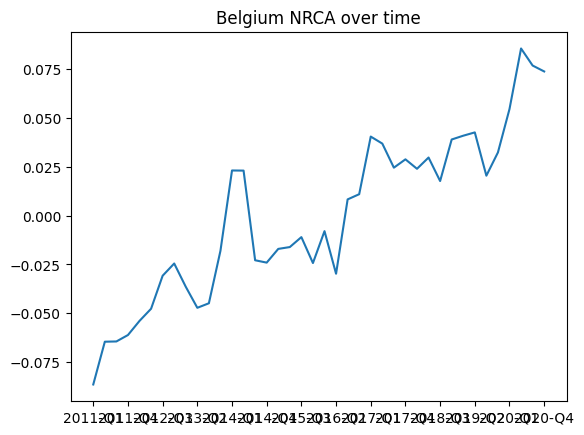

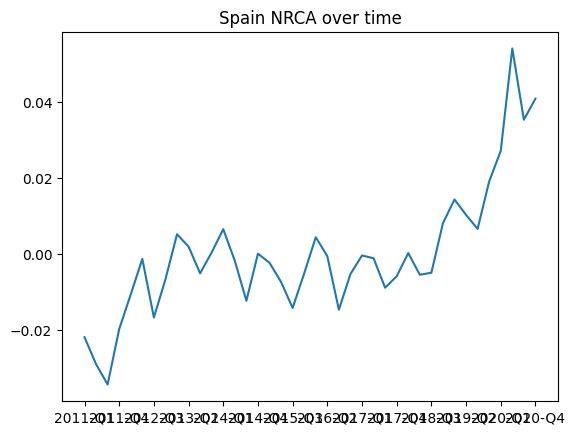

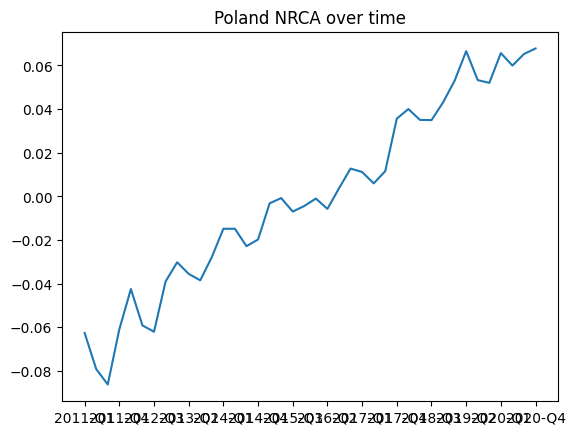

In [6]:
# Calculate country-level mean NRCA over time
# Step 1: multiply the value by the share of such workers.
for country in countries:
    combined[f"multip_{country}_NRCA"] = combined[f"std_{country}_NRCA"] * combined[f"share_{country}"]

# Step 2: sum it up (it becomes another weighted mean)
aggs = {}
for country in countries:
    aggs[country] = combined.groupby(["TIME"])[f"multip_{country}_NRCA"].sum().reset_index()

# Plot the results
import matplotlib.pyplot as plt

for country in countries:
    plt.figure()
    agg = aggs[country]
    plt.plot(agg["TIME"], agg[f"multip_{country}_NRCA"])
    plt.xticks(range(0, len(agg), 3), agg["TIME"][::3])
    plt.title(f"{country} NRCA over time")
    plt.show()

# If this code gets automated and cleaned properly,
# you should be able to easily add other countries as well as other tasks.
# E.g.:
# Routine manual
# 4.A.3.a.3 Controlling Machines and Processes
# 4.C.2.d.1.i Spend Time Making Repetitive Motions
# 4.C.3.d.3 Pace Determined by Speed of Equipment